In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from k_regular_graph_generator import generate_multiple_k_regular_graphs
from ql_bit_generator import generate_quantum_like_bit, visualize_ql_bit
from eigenvalue_analysis import *
from bell_state_generation import *
from cartesian_prod_complete import *

np.set_printoptions(threshold=15000)

In [210]:
def update_ql_coupling(matrix, N_sizes, ql_bit_i, ql_bit_j, coupling_type='alternating'):
    """
    Update coupling between two specific QL bits
    
    Parameters:
    - matrix: adjacency matrix to modify
    - N_sizes: list of subgraph sizes for each QL bit
    - ql_bit_i, ql_bit_j: indices of the two QL bits to couple
    - coupling_type: 'pos' (+1), 'neg' (-1), 'alternating' (+1/-1), or specific value
    """
    
    # Calculate nodes per QL bit and cumulative start positions
    nodes_per_ql = [2 * N for N in N_sizes]
    ql_bit_starts = [0]
    for i in range(len(N_sizes)):
        ql_bit_starts.append(ql_bit_starts[-1] + nodes_per_ql[i])
    
    # Get start/end positions for the two QL bits
    start_i = ql_bit_starts[ql_bit_i]
    end_i = ql_bit_starts[ql_bit_i + 1]
    start_j = ql_bit_starts[ql_bit_j]
    end_j = ql_bit_starts[ql_bit_j + 1]
    
    print(f"Updating coupling between QL bit {ql_bit_i} (nodes {start_i}-{end_i-1}) and QL bit {ql_bit_j} (nodes {start_j}-{end_j-1})")
    
    # Update the coupling
    for row in range(start_i, end_i):
        for col in range(start_j, end_j):
            if matrix[row, col] != 0:  # Only modify existing connections
                if coupling_type == 'pos':
                    sign = 1
                elif coupling_type == 'neg':
                    sign = -1
                elif coupling_type == 'alternating':
                    sign = 1 if (row + col) % 2 == 0 else -1
                else:
                    # Assume it's a specific numeric value
                    sign = coupling_type
                
                matrix[row, col] = sign
                matrix[col, row] = sign  # Maintain symmetry
    
    return matrix

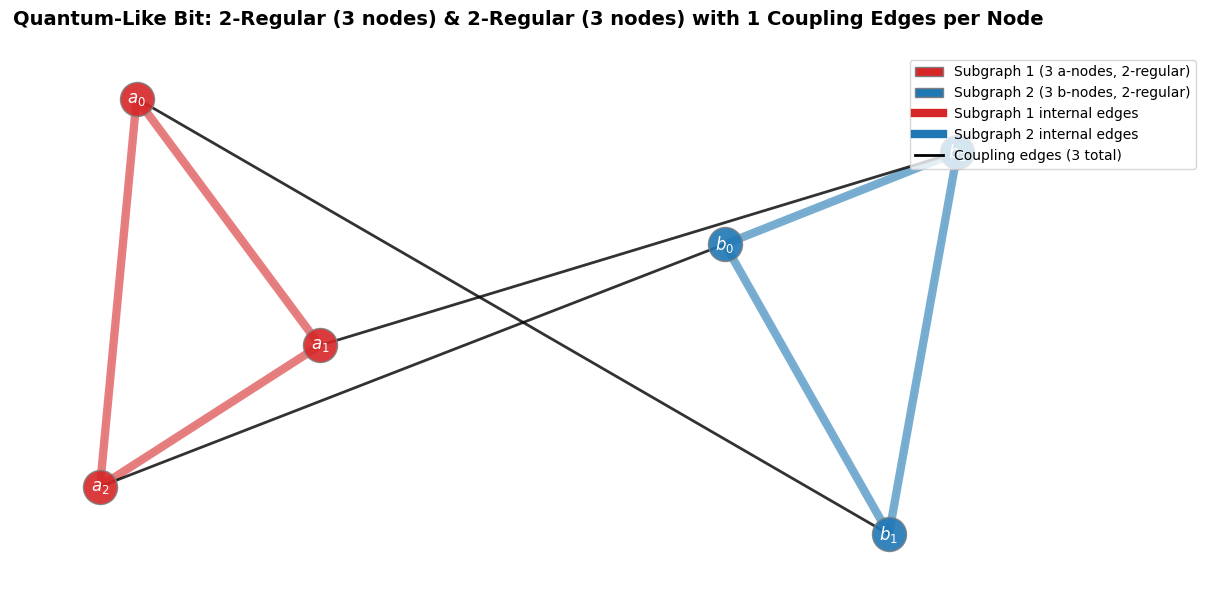

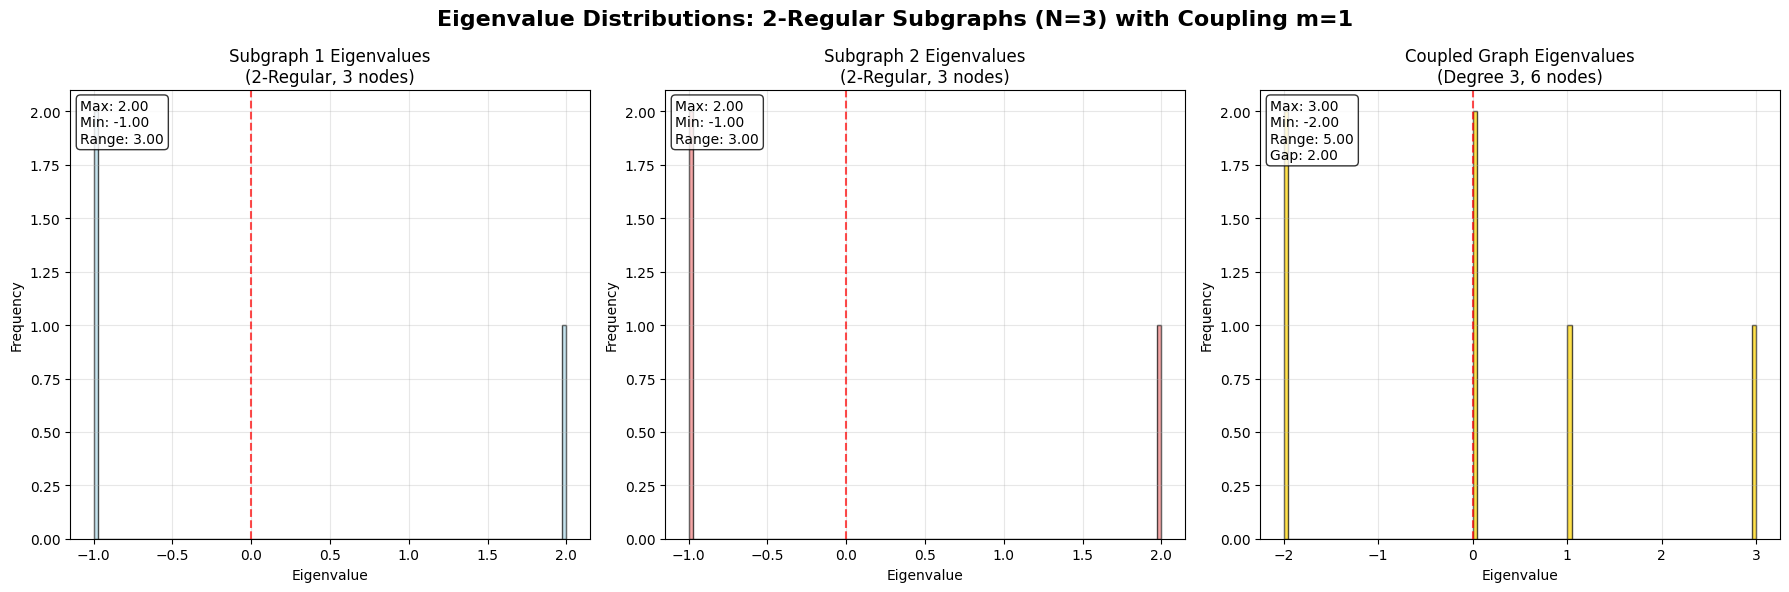

(<Figure size 1800x600 with 3 Axes>,
 (array([ 2., -1., -1.]),
  array([ 2., -1., -1.]),
  array([ 3.00000000e+00,  1.00000000e+00,  1.91381734e-16, -1.03782917e-16,
         -2.00000000e+00, -2.00000000e+00])))

In [280]:
N = 3
k = 2
l = 1
coupled_matrix, info = generate_quantum_like_bit(N, k, N, k, l)
visualize_ql_bit(coupled_matrix, info)
visualize_eigenvalue_distribution(coupled_matrix, info)

In [281]:
coupled_matrix

array([[0, 1, 1, 0, 1, 0],
       [1, 0, 1, 0, 0, 1],
       [1, 1, 0, 1, 0, 0],
       [0, 0, 1, 0, 1, 1],
       [1, 0, 0, 1, 0, 1],
       [0, 1, 0, 1, 1, 0]])

In [282]:
evals, evecs = np.linalg.eigh(coupled_matrix)
evals, evecs

(array([-2.00000000e+00, -2.00000000e+00, -2.54294073e-16,  9.00187066e-16,
         1.00000000e+00,  3.00000000e+00]),
 array([[ 0.06208405,  0.57400253,  0.57432741,  0.05900309, -0.40824829,
          0.40824829],
        [-0.5281428 , -0.2332349 , -0.33826188,  0.46788058, -0.40824829,
          0.40824829],
        [ 0.46605875, -0.34076763, -0.23606553, -0.52688367, -0.40824829,
          0.40824829],
        [-0.46605875,  0.34076763, -0.23606553, -0.52688367,  0.40824829,
          0.40824829],
        [-0.06208405, -0.57400253,  0.57432741,  0.05900309,  0.40824829,
          0.40824829],
        [ 0.5281428 ,  0.2332349 , -0.33826188,  0.46788058,  0.40824829,
          0.40824829]]))

In [283]:
v_h = 1/np.sqrt(2) * np.array([[1, 1],[1, -1]])
ones = np.eye(N)

v_h, ones

(array([[ 0.70710678,  0.70710678],
        [ 0.70710678, -0.70710678]]),
 array([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]]))

In [284]:
U_cb = np.kron(v_h, ones)
U_cb

array([[ 0.70710678,  0.        ,  0.        ,  0.70710678,  0.        ,
         0.        ],
       [ 0.        ,  0.70710678,  0.        ,  0.        ,  0.70710678,
         0.        ],
       [ 0.        ,  0.        ,  0.70710678,  0.        ,  0.        ,
         0.70710678],
       [ 0.70710678,  0.        ,  0.        , -0.70710678, -0.        ,
        -0.        ],
       [ 0.        ,  0.70710678,  0.        , -0.        , -0.70710678,
        -0.        ],
       [ 0.        ,  0.        ,  0.70710678, -0.        , -0.        ,
        -0.70710678]])

In [285]:
psi_up = 1/np.sqrt(2) * np.array([
    [0.40824829], [0.40824829], [0.40824829],
    [0.40824829], [0.40824829], [0.40824829] 
    ])

psi_down = 1/np.sqrt(2) * np.array([
    [0.40824829], [0.40824829], [0.40824829],
    [-0.40824829], [-0.40824829], [-0.40824829] 
    ])

In [286]:
psi_up

array([[0.28867513],
       [0.28867513],
       [0.28867513],
       [0.28867513],
       [0.28867513],
       [0.28867513]])

In [292]:
cb_up = np.round(np.matmul(U_cb, psi_up) / max(np.matmul(U_cb, psi_up)), 3)
cb_down = np.round(np.matmul(U_cb, psi_down) / max(np.matmul(U_cb, psi_down)), 3)

print('For 1 QL bit made from N = 3 subgraphs the... \n')
print(f'Up state in computational basis is \n {cb_up}')
print('\n')
print(f'Down state in computational basis is \n {cb_down}')

For 1 QL bit made from N = 3 subgraphs the... 

Up state in computational basis is 
 [[1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]]


Down state in computational basis is 
 [[0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]]


In [339]:
X_gate = np.array([
    [0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0], 
    [0, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 0, 0], 
    [0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0],
])

Y_gate = np.array([
    [0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0], 
    [0, 0, 0, 0, 0, 1],
    [-1, 0, 0, 0, 0, 0], 
    [0, -1, 0, 0, 0, 0],
    [0, 0, -1, 0, 0, 0],
])

Z_gate = np.array([
    [1, 0, 0, 0, 0, 0], 
    [0, 1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0],
    [0, 0, 0, -1, 0, 0],
    [0, 0, 0, 0, -1, 0], 
    [0, 0, 0, 0, 0, -1],
])

In [328]:
X_gate.shape

(6, 6)

In [366]:
test = np.matmul(X_gate, coupled_matrix)
test  = np.matmul(Z_gate, np.matmul(X_gate, np.matmul(Z_gate, test)))

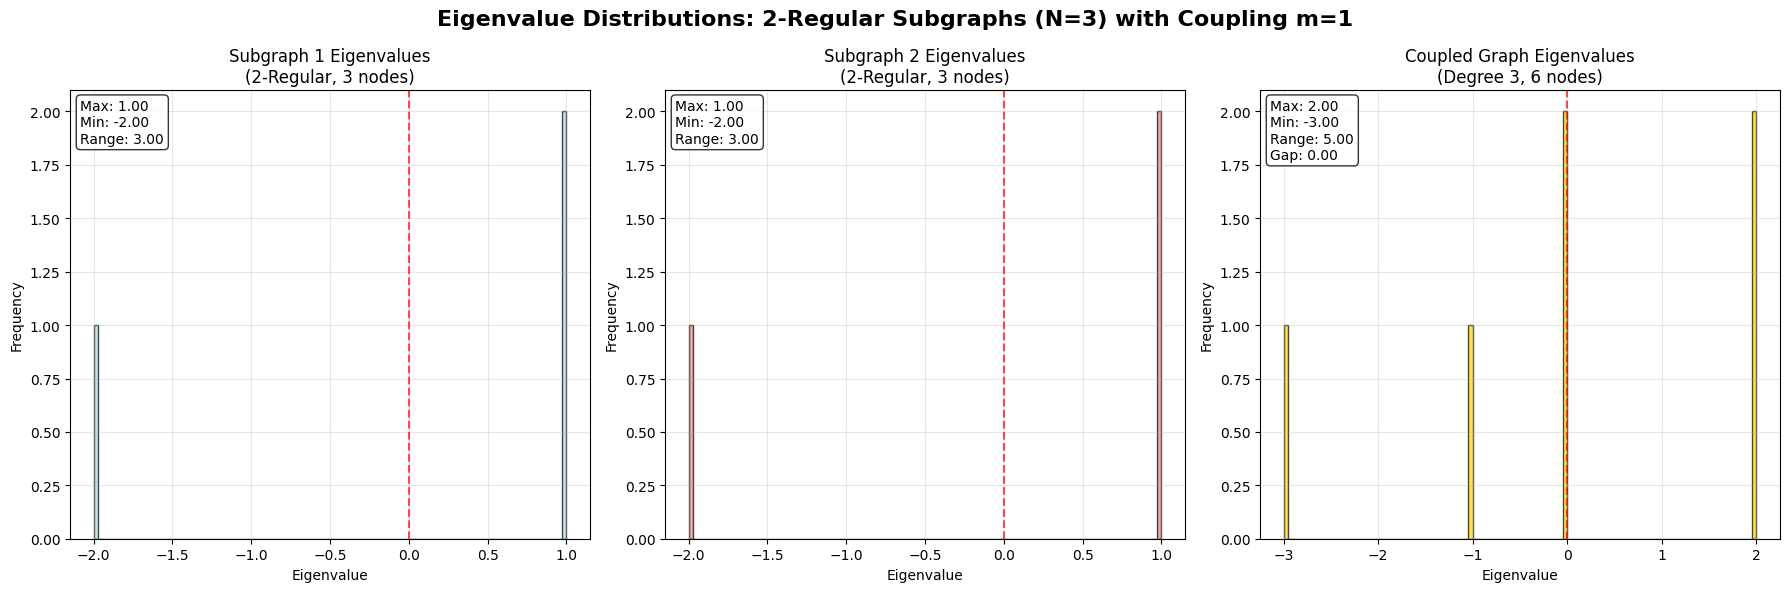

(<Figure size 1800x600 with 3 Axes>,
 (array([ 1.,  1., -2.]),
  array([ 1.,  1., -2.]),
  array([ 2.00000000e+00,  2.00000000e+00,  1.03782917e-16, -1.91381734e-16,
         -1.00000000e+00, -3.00000000e+00])))

In [367]:
visualize_eigenvalue_distribution(test, info)

### A workthrough of the computational basis projection for 2 QL bits before and after coupling

In [217]:
N, k, base_l = 20, 10, 1
# ql_bit_base = generate_quantum_like_bit(N, k, N, k, base_l)

N1, k1 = 20, 10
N2, k2 = 20, 10
ql_bit_base = generate_quantum_like_bit(N1, k1, N2, k2, base_l)


# Comlete graph size
m = 2

# # Option 1: Different l values per node
l_per_node = [1] # l value for each of the nodes
product = cartesian_product_ql_complete_variable_l(
    ql_bit_base, m, l_per_node, N, k)

In [218]:
# Example usage:
N_sizes = [20, 20]  # QL bit sizes
matrix = product.copy()

# Set coupling between QL bits 0 and 1 to all +1
#matrix = update_ql_coupling(matrix, N_sizes, 0, 1, 'neg')

# Or set to all -1
# matrix = update_ql_coupling(matrix, N_sizes, 0, 1, 'neg')

# Or set to alternating +1/-1
# matrix = update_ql_coupling(matrix, N_sizes, 0, 1, 'alternating')

# Or set to a specific value like 2
matrix = update_ql_coupling(matrix, N_sizes, 0, 1, 0)

print("Coupling updated between specified QL bits")

Updating coupling between QL bit 0 (nodes 0-39) and QL bit 1 (nodes 40-79)
Coupling updated between specified QL bits


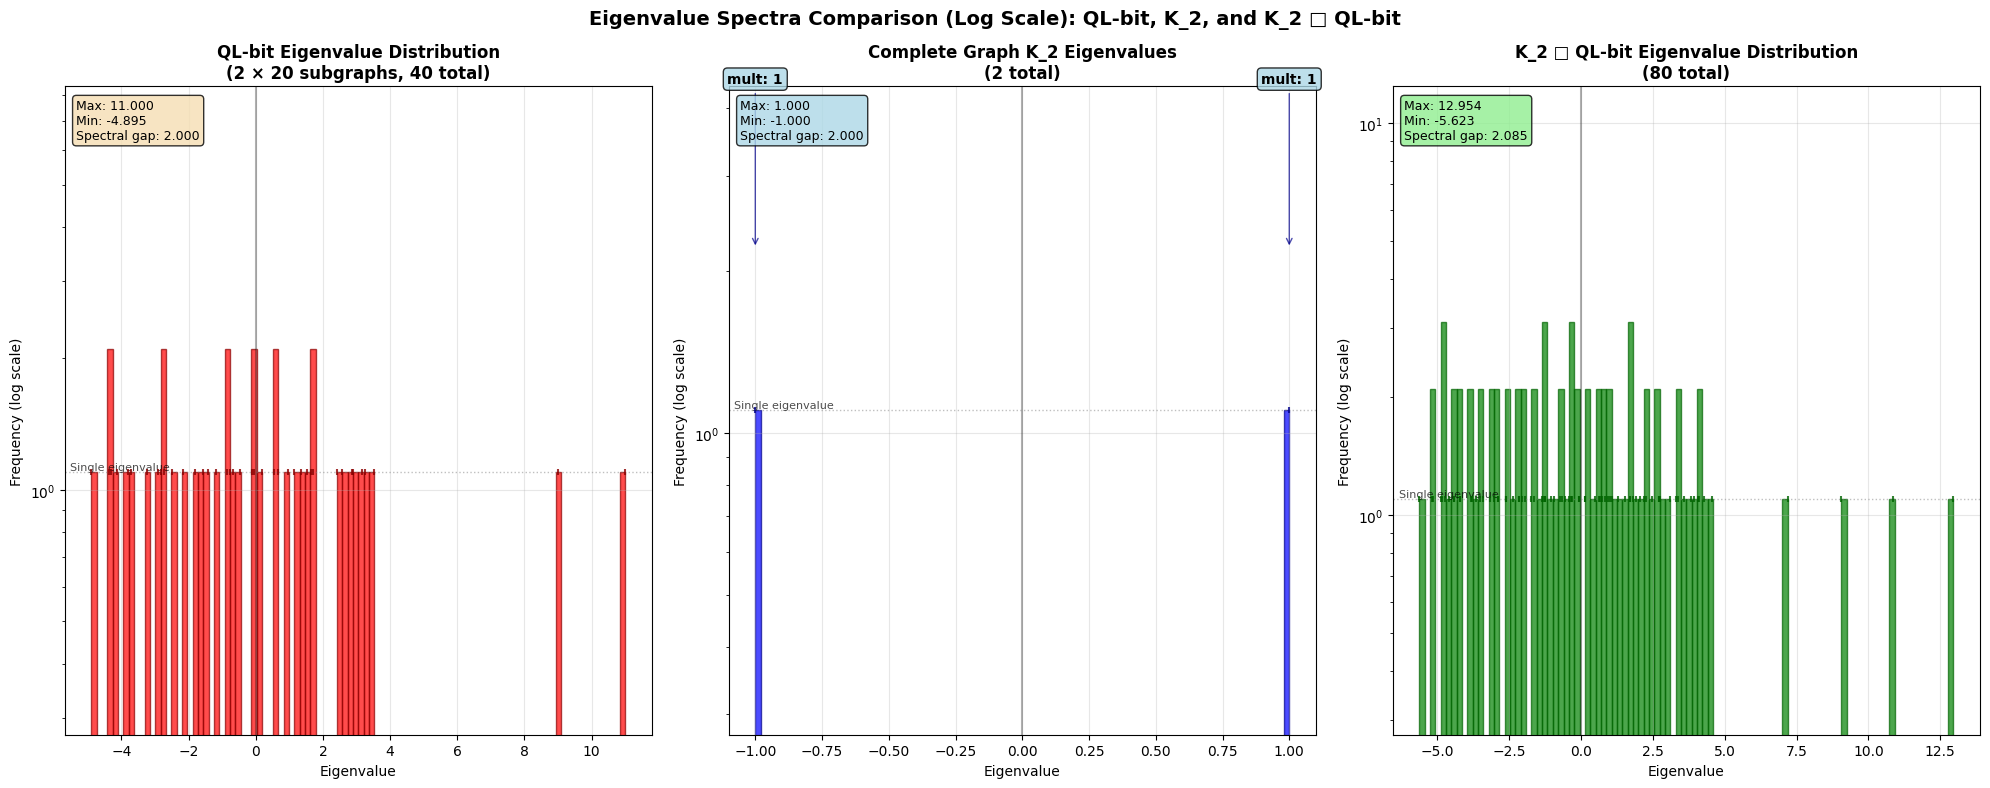


Eigenvalue Analysis:
QL-bit (40 nodes):
  Largest eigenvalue: 11.000000
  Smallest eigenvalue: -4.895324
  Spectral radius: 11.000000
  Unique eigenvalues: 40
  Top 100 eigenvalues: [11.          9.          3.52034557  3.25294952  3.17067904  2.90199766
  2.85215481  2.58229128  2.4273635   1.70621547  1.6353426   1.5332499
  1.33512308  1.14809724  0.97453407  0.66448682  0.53680103  0.18161515
 -0.05810425 -0.10237438 -0.46760108 -0.66358919 -0.76369394 -0.86293724
 -1.1713838  -1.42119905 -1.55783729 -1.80843609 -2.17381329 -2.48029782
 -2.71599567 -2.81301125 -2.92032362 -3.23331995 -3.69979361 -3.78850614
 -4.14093946 -4.31915709 -4.36560848 -4.89532403]
  First 5 eigenvectors (columns, top 100 elements):
    Eigenvector 1 (λ=11.000000): [-0.15811388 -0.15811388 -0.15811388 -0.15811388 -0.15811388 -0.15811388
 -0.15811388 -0.15811388 -0.15811388 -0.15811388 -0.15811388 -0.15811388
 -0.15811388 -0.15811388 -0.15811388 -0.15811388 -0.15811388 -0.15811388
 -0.15811388 -0.15811388 -

(array([11.        ,  9.        ,  3.52034557,  3.25294952,  3.17067904,
         2.90199766,  2.85215481,  2.58229128,  2.4273635 ,  1.70621547,
         1.6353426 ,  1.5332499 ,  1.33512308,  1.14809724,  0.97453407,
         0.66448682,  0.53680103,  0.18161515, -0.05810425, -0.10237438,
        -0.46760108, -0.66358919, -0.76369394, -0.86293724, -1.1713838 ,
        -1.42119905, -1.55783729, -1.80843609, -2.17381329, -2.48029782,
        -2.71599567, -2.81301125, -2.92032362, -3.23331995, -3.69979361,
        -3.78850614, -4.14093946, -4.31915709, -4.36560848, -4.89532403]),
 array([ 1., -1.]),
 array([12.95367441, 10.86908666,  9.05528597,  7.18644473,  4.5435016 ,
         4.29235921,  4.10025976,  4.06947697,  3.93342981,  3.8157604 ,
         3.58070668,  3.36292624,  3.31283437,  3.08444646,  2.74589796,
         2.71815078,  2.71074844,  2.47991459,  2.24739114,  2.19156081,
         2.05030977,  1.92151423,  1.79701357,  1.71610568,  1.69770551,
         1.52368275,  1.29669

In [220]:
visualize_eigenvalues(ql_bit_base, product, m, N)

In [265]:
evals, evecs = np.linalg.eigh(product)
evals

array([-5.62332826, -5.17708031, -5.13527903, -4.87908186, -4.84743044,
       -4.73688553, -4.58849484, -4.41576429, -4.41215656, -4.2160409 ,
       -4.2065758 , -3.83128871, -3.80323092, -3.66053593, -3.49880224,
       -3.41075035, -3.15215758, -3.02993965, -2.88519257, -2.88390022,
       -2.6244472 , -2.62175109, -2.36360999, -2.15329814, -2.14902715,
       -2.04278383, -1.93044143, -1.72212039, -1.62305665, -1.36000181,
       -1.33578449, -1.2556432 , -1.25352806, -1.05781639, -0.92975785,
       -0.71546394, -0.64867181, -0.53991945, -0.40078957, -0.352559  ,
       -0.31495444, -0.06416892, -0.05474244,  0.1445279 ,  0.14977487,
        0.47628774,  0.62562987,  0.66156902,  0.71809317,  0.8313943 ,
        0.92623641,  1.02553797,  1.09231509,  1.29669837,  1.52368275,
        1.69770551,  1.71610568,  1.79701357,  1.92151423,  2.05030977,
        2.19156081,  2.24739114,  2.47991459,  2.71074844,  2.71815078,
        2.74589796,  3.08444646,  3.31283437,  3.36292624,  3.58

In [278]:
evecs[:, -10]

array([ 0.08130611, -0.14204509,  0.07712601, -0.02855215, -0.02735133,
       -0.03397202,  0.0057128 , -0.01929945,  0.01459654,  0.05660163,
       -0.00734777,  0.04269732, -0.09994865,  0.03234465, -0.03150846,
        0.01774518,  0.06197261, -0.06420332,  0.04068384, -0.0413145 ,
       -0.15979814,  0.27437482, -0.35755106,  0.21469796, -0.03318971,
        0.1717519 , -0.09000609, -0.0648872 , -0.1071245 ,  0.14518921,
        0.16494584, -0.07211448,  0.10868448, -0.05138279,  0.05473708,
       -0.11961002,  0.0369773 ,  0.07892888, -0.00892667, -0.11453179,
       -0.08130611,  0.14204509, -0.07712601,  0.02855215,  0.02735133,
        0.03397202, -0.0057128 ,  0.01929945, -0.01459654, -0.05660163,
        0.00734777, -0.04269732,  0.09994865, -0.03234465,  0.03150846,
       -0.01774518, -0.06197261,  0.06420332, -0.04068384,  0.0413145 ,
        0.15979814, -0.27437482,  0.35755106, -0.21469796,  0.03318971,
       -0.1717519 ,  0.09000609,  0.0648872 ,  0.1071245 , -0.14

In [259]:
ones = np.eye(N1)
v_h_mat = 1/np.sqrt(2) * np.array([[1, 1],[1, -1]])
U_cb_mat = np.kron(v_h, ones)


In [260]:
psi_up = 1/np.sqrt(2) * np.array([
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388], 
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388], 
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388], 
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388],
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388], 
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388], 
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388], 
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388] 
    ])

psi_down = 1/np.sqrt(2) * np.array([
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388], 
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388], 
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388], 
    [0.15811388], [0.15811388], [0.15811388], [0.15811388], [0.15811388],
    [-0.15811388], [-0.15811388], [-0.15811388], [-0.15811388], [-0.15811388],
    [-0.15811388], [-0.15811388], [-0.15811388], [-0.15811388], [-0.15811388], 
    [-0.15811388], [-0.15811388], [-0.15811388], [-0.15811388], [-0.15811388], 
    [-0.15811388], [-0.15811388], [-0.15811388], [-0.15811388], [-0.15811388] 
    ])

In [264]:
cb_up_mat = np.round(np.matmul(U_cb_mat, psi_up), 5)
cb_down_mat = np.round(np.matmul(U_cb_mat, psi_down), 5)

print('For 1 QL bit made from N = 3 subgraphs the... \n')
print(f'Up state in computational basis is \n {cb_up_mat}')
print('\n')
print(f'Down state in computational basis is \n {cb_down_mat}')

For 1 QL bit made from N = 3 subgraphs the... 

Up state in computational basis is 
 [[0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]]


Down state in computational basis is 
 [[0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.     ]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.15811]
 [0.

In [272]:
psi_up_prod = 1/np.sqrt(2) * np.array([
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682],
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682], 
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682], 
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682],
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682], 
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682], 
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682], 
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682] 
    ])

psi_down_prod = 1/np.sqrt(2) * np.array([
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682],
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682], 
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682], 
    [0.11254682], [0.11254682], [0.11254682], [0.11254682], [0.11254682],
    [-0.11254682], [-0.11254682], [-0.11254682], [-0.11254682], [-0.11254682],
    [-0.11254682], [-0.11254682], [-0.11254682], [-0.11254682], [-0.11254682], 
    [-0.11254682], [-0.11254682], [-0.11254682], [-0.11254682], [-0.11254682], 
    [-0.11254682], [-0.11254682], [-0.11254682], [-0.11254682], [-0.11254682]
    ])

In [273]:
cb_up_prod = np.round(np.matmul(U_cb_mat, psi_up_prod), 5)
cb_down_prod = np.round(np.matmul(U_cb_mat, psi_down_prod), 5)

print('For 1 QL bit made from N = 3 subgraphs the... \n')
print(f'Up state in computational basis is \n {cb_up_prod}')
print('\n')
print(f'Down state in computational basis is \n {cb_down_prod}')

For 1 QL bit made from N = 3 subgraphs the... 

Up state in computational basis is 
 [[ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]]


Down state in computational basis is 
 [[ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [ 0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]
 [-0.     ]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.11255]
 [ 0.1125

In [ ]:
# See what happens to psi_up, psi_down when gates are applied for different intializations, matrix vs product, up to + state valid operation...
# Will the final measurement of psi depend on intialization or updated U_cb calcs
# Gate operation on whole adjacency matrix or just single QL bit(s), one (two) ql bit gates, what happens to eigenvalues
# Normalize psi_up, psi_down to 1s at initialization
